# Cálculo de magnitud local $M_L$

Este notebook calcula la magnitud local $M_L$ del evento de la Actividad 3 a partir de los sismogramas sintéticos Wood--Anderson contenidos en la carpeta `DatosWA`.

Los archivos están expresados en desplazamiento físico, en metros, y para el cálculo de $M_L$ se emplean únicamente las componentes horizontales E y N de cada estación. Las estaciones consideradas son:

- MNMCX
- PATA
- PSGCX
- UNAP
- PB07

Para cada componente horizontal se identifica la amplitud máxima absoluta:

$$
A_{\max} = \max |u(t)|.
$$

La amplitud se convierte de metros a milímetros y se utiliza la relación entregada en la actividad:

$$
M_L = \log_{10}(A_{\mathrm{mm}})
+ \log_{10}\left(\frac{\Delta}{100}\right)
+ 3,
$$

donde:

- $A_{\mathrm{mm}}$ es la amplitud máxima en milímetros;
- $\Delta$ es la distancia epicentral de la estación en kilómetros.

Primero se calcula $M_L$ para cada componente horizontal; luego se promedian las componentes E y N para obtener una magnitud por estación; finalmente, se promedian las cinco estaciones para obtener la magnitud local final del evento.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt

mpl.rcParams.update({
    "figure.facecolor": "white",
    "figure.edgecolor": "white",
    "axes.facecolor": "white",
    "axes.edgecolor": "black",
    "axes.labelcolor": "black",
    "axes.titlecolor": "black",
    "xtick.color": "black",
    "ytick.color": "black",
    "text.color": "black",
    "grid.color": "lightgray",
    "grid.alpha": 0.5,
    "savefig.facecolor": "white",
    "savefig.edgecolor": "white",
    "savefig.transparent": False,
})

plt.rcParams["figure.figsize"] = (14, 4)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.25
plt.rcParams["font.size"] = 11

RUTA_DATOS = Path(
    "/Week3/Task_Files/datos_actividad3/DatosWA"
)

DISTANCIAS_EPICENTRALES_KM = {
    "MNMCX": 113.7,
    "PATA": 93.0,
    "PSGCX": 100.7,
    "UNAP": 84.8,
    "PB07": 185.9,
}

COMPONENTES_HORIZONTALES = ("HHE", "HHN")

if not RUTA_DATOS.exists():
    raise FileNotFoundError(
        f"No existe la carpeta de datos:\n{RUTA_DATOS}"
    )

print(f"Carpeta de datos:\n{RUTA_DATOS}\n")
print("Archivos disponibles:")

for archivo in sorted(RUTA_DATOS.glob("*.dat")):
    print(" -", archivo.name)

Carpeta de datos:
/home/keneth/Documents/Academic_Projects/AGCID2026_DIS_UChile/Week3/Task_Files/datos_actividad3/DatosWA

Archivos disponibles:
 - CX.MNMCX..HHE.dat
 - CX.MNMCX..HHN.dat
 - CX.PB07..HHE.dat
 - CX.PB07..HHN.dat
 - CX.PSGCX..HHE.dat
 - CX.PSGCX..HHN.dat
 - IQ.PATA..HHE.dat
 - IQ.PATA..HHN.dat
 - IQ.UNAP..HHE.dat
 - IQ.UNAP..HHN.dat


## 1. Lectura automática de todas las trazas Wood--Anderson

La función siguiente identifica los archivos `.dat` de la carpeta `DatosWA`, obtiene la red, estación y componente a partir de sus nombres y carga únicamente las componentes horizontales necesarias para calcular $M_L$.

Por ejemplo, para un archivo llamado:

```text
CX.MNMCX..HHE.dat
```

se identifica:

- Red: `CX`
- Estación: `MNMCX`
- Componente: `HHE`

Los archivos se leen como dos columnas:

- `t_s`: tiempo en segundos;
- `amplitud_m`: amplitud en metros.

In [2]:
def interpretar_nombre_archivo(nombre):
    """
    Extrae red, estación y componente desde nombres como:
    CX.MNMCX..HHE.dat
    IQ.PATA..HHN.dat
    """
    partes = nombre.split(".")

    if len(partes) < 4:
        raise ValueError(f"Formato de nombre no reconocido: {nombre}")

    red = partes[0]
    estacion = partes[1]
    componente = partes[-2]

    return red, estacion, componente


def leer_traza_wa(ruta):
    """
    Lee un archivo .dat Wood-Anderson con dos columnas:
    tiempo [s] y amplitud [m].
    """
    df = pd.read_csv(
        ruta,
        sep=r"\s+",
        names=["t_s", "amplitud_m"],
        engine="python"
    )

    df = df.dropna().sort_values("t_s").reset_index(drop=True)

    return df


def cargar_trazas_wa(carpeta, estaciones_validas, componentes_validas):
    """
    Carga todas las trazas horizontales de las estaciones seleccionadas.
    """
    trazas = {}
    no_utilizados = []

    for ruta in sorted(Path(carpeta).glob("*.dat")):
        red, estacion, componente = interpretar_nombre_archivo(ruta.name)

        if estacion not in estaciones_validas:
            no_utilizados.append(ruta.name)
            continue

        if componente not in componentes_validas:
            no_utilizados.append(ruta.name)
            continue

        trazas[(estacion, componente)] = {
            "red": red,
            "archivo": ruta.name,
            "datos": leer_traza_wa(ruta)
        }

    return trazas, no_utilizados


trazas_wa, archivos_no_utilizados = cargar_trazas_wa(
    carpeta=RUTA_DATOS,
    estaciones_validas=DISTANCIAS_EPICENTRALES_KM,
    componentes_validas=COMPONENTES_HORIZONTALES
)

if not trazas_wa:
    raise RuntimeError(
        "No se cargaron trazas horizontales. "
        "Revise la ruta y los nombres de los archivos."
    )

resumen_archivos = pd.DataFrame([
    {
        "Estación": estacion,
        "Componente": componente,
        "Red": info["red"],
        "Archivo": info["archivo"],
        "Número de muestras": len(info["datos"]),
        "Duración [s]": (
            info["datos"]["t_s"].iloc[-1]
            - info["datos"]["t_s"].iloc[0]
        )
    }
    for (estacion, componente), info in trazas_wa.items()
]).sort_values(
    ["Estación", "Componente"]
).reset_index(drop=True)

if archivos_no_utilizados:
    print("\nArchivos no utilizados para ML:")
    print(
        "Estos archivos no pertenecen a una de las cinco estaciones "
        "requeridas o no corresponden a componentes HHE/HHN."
    )

    for nombre in archivos_no_utilizados:
        print(" -", nombre)


resumen_archivos

,Estación,Componente,Red,Archivo,Número de muestras,Duración [s]
0,MNMCX,HHE,CX,CX.MNMCX..HHE.dat,17001,170.0
1,MNMCX,HHN,CX,CX.MNMCX..HHN.dat,17001,170.0
2,PATA,HHE,IQ,IQ.PATA..HHE.dat,17001,170.0
3,PATA,HHN,IQ,IQ.PATA..HHN.dat,17001,170.0
4,PB07,HHE,CX,CX.PB07..HHE.dat,17001,170.0
5,PB07,HHN,CX,CX.PB07..HHN.dat,17001,170.0
6,PSGCX,HHE,CX,CX.PSGCX..HHE.dat,17001,170.0
7,PSGCX,HHN,CX,CX.PSGCX..HHN.dat,17001,170.0
8,UNAP,HHE,IQ,IQ.UNAP..HHE.dat,17001,170.0
9,UNAP,HHN,IQ,IQ.UNAP..HHN.dat,17001,170.0


## 2. Gráfico de todas las señales horizontales

A continuación se representan todas las trazas Wood--Anderson utilizadas en el cálculo. Cada panel corresponde a una estación y a una componente horizontal.

La inspección visual permite verificar:

1. La presencia del paquete de ondas asociado al evento.
2. La calidad general de la señal.
3. La ubicación temporal de la amplitud máxima.
4. La existencia de ruido o de posibles máximos que no pertenezcan al evento.

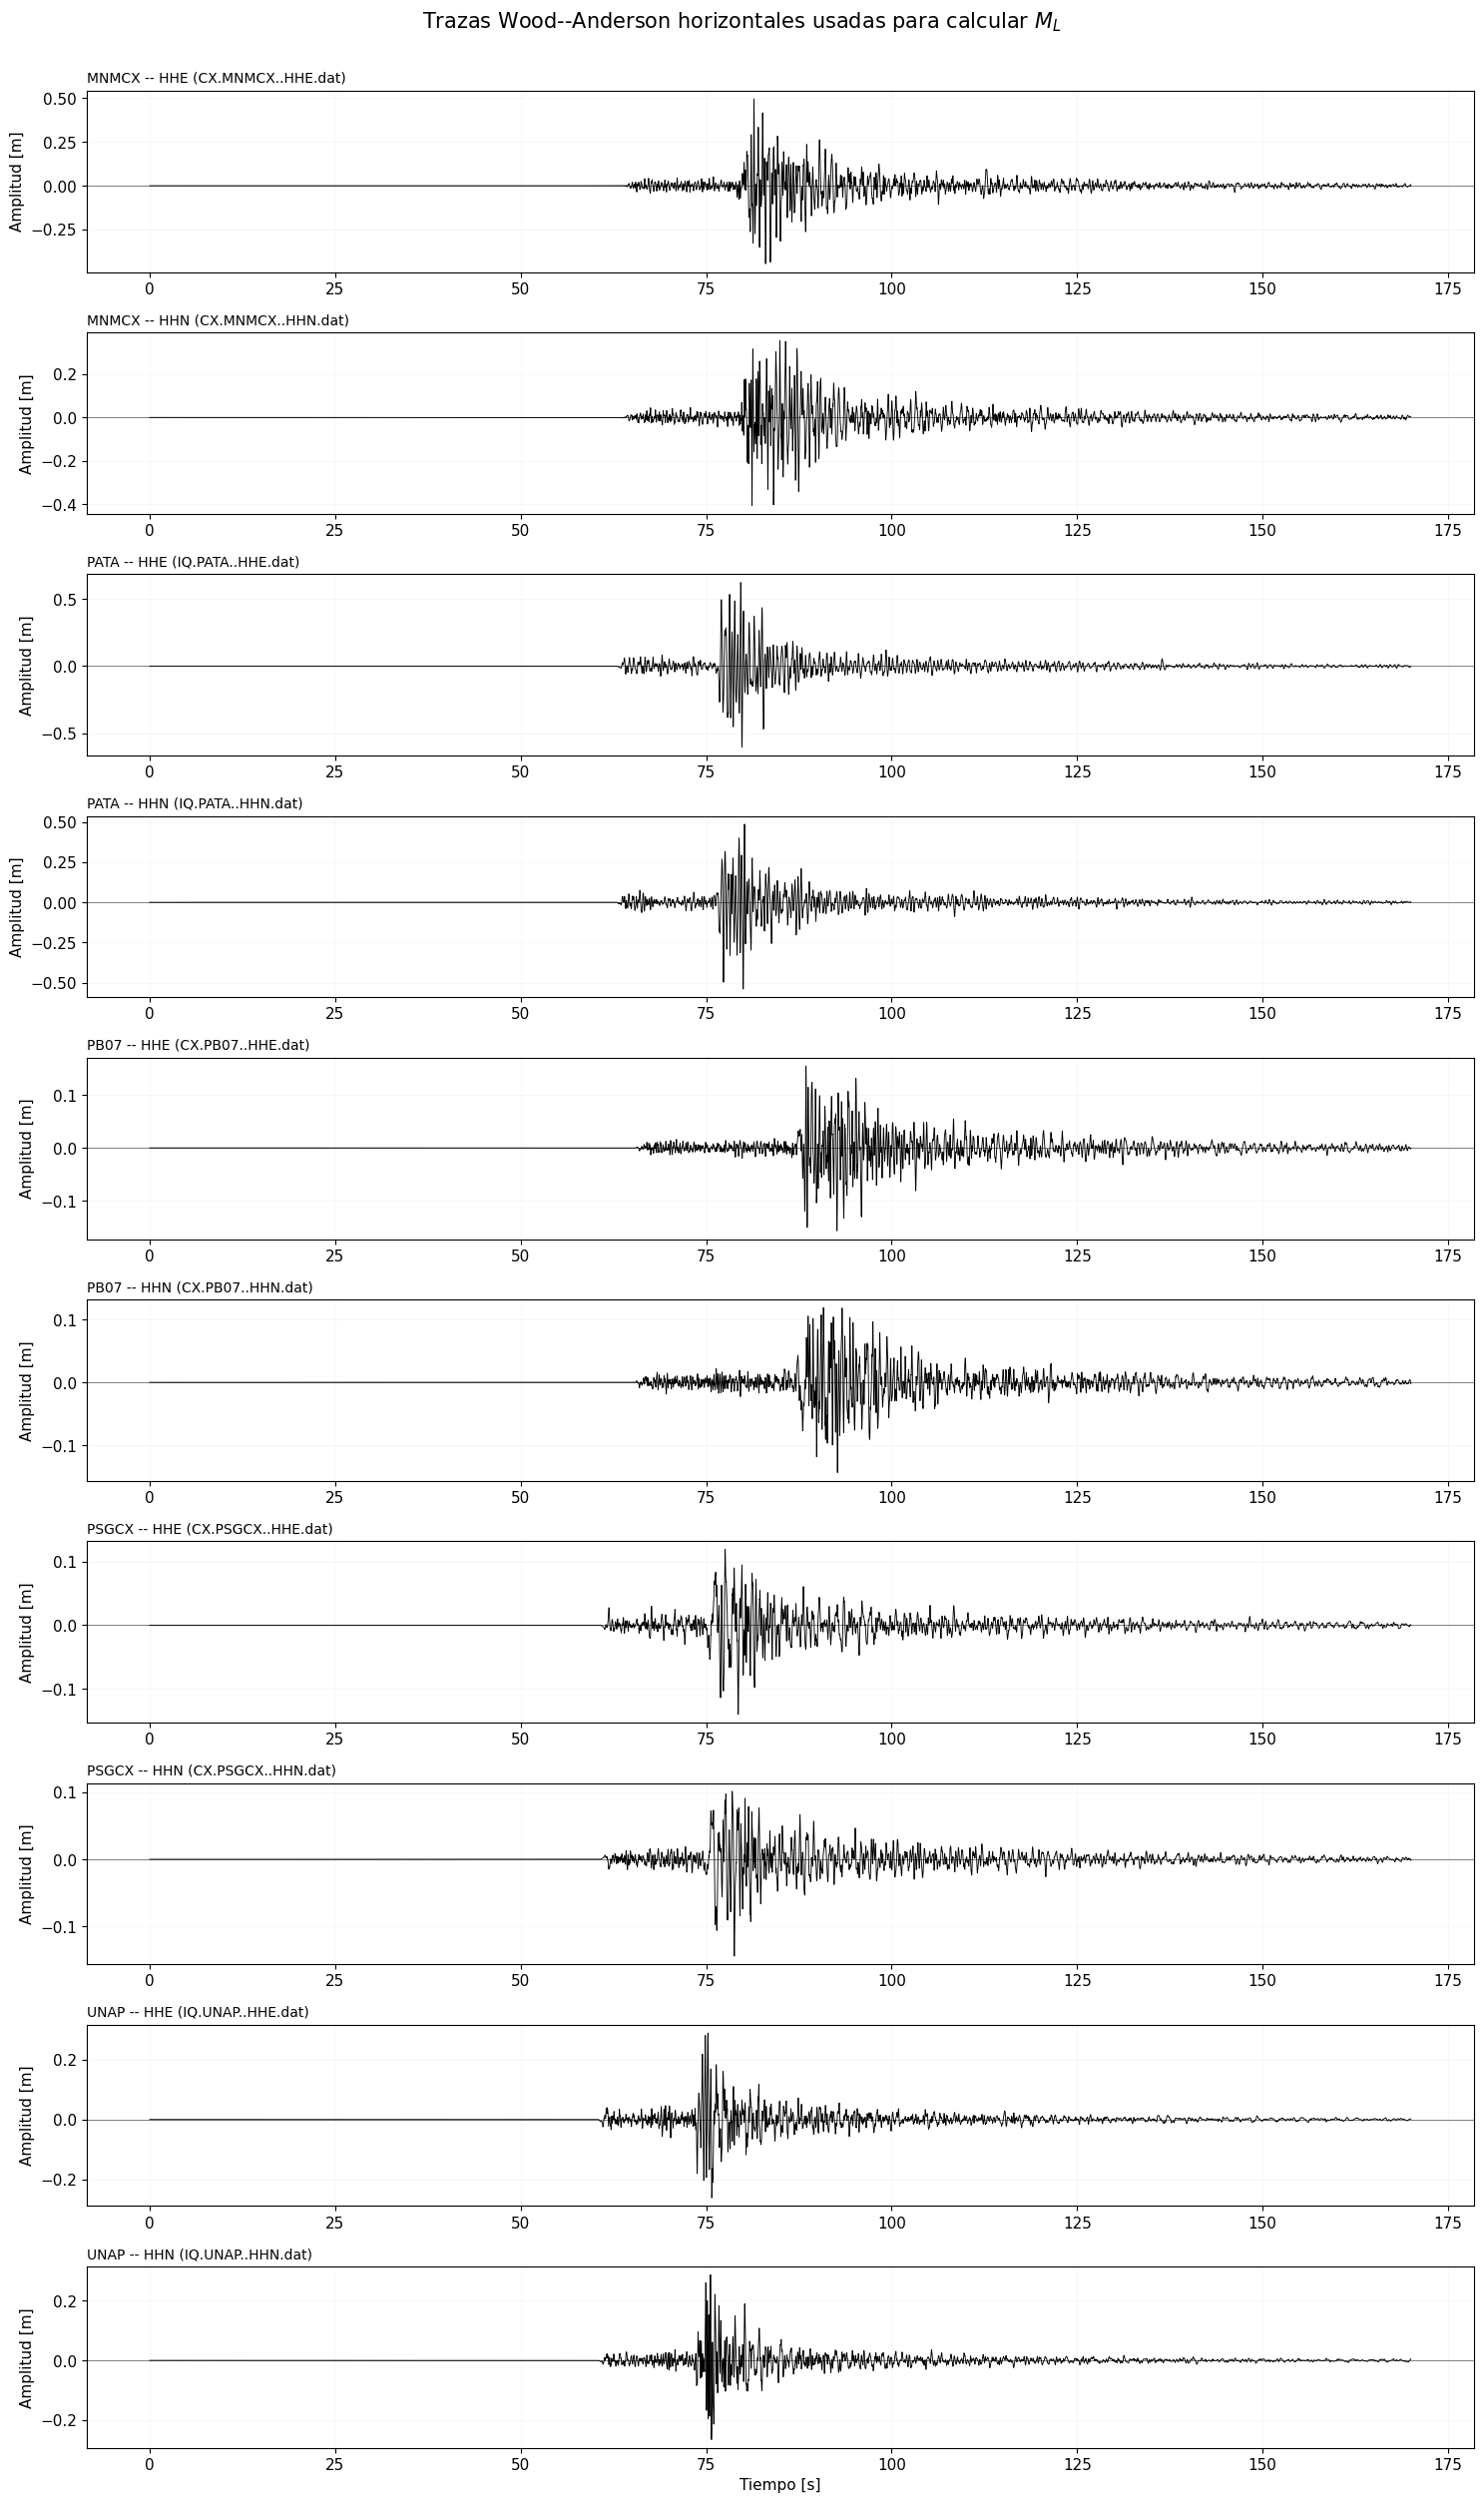

In [3]:
n_trazas = len(trazas_wa)

fig, axes = plt.subplots(
    n_trazas,
    1,
    figsize=(15, max(2.5 * n_trazas, 8)),
    sharex=False
)

axes = np.atleast_1d(axes)

for ax, ((estacion, componente), info) in zip(
    axes,
    sorted(trazas_wa.items())
):
    datos = info["datos"]

    ax.axhline(0, color="gray", lw=0.7)

    ax.plot(
        datos["t_s"],
        datos["amplitud_m"],
        color="black",
        lw=0.65
    )

    ax.set_title(
        f"{estacion} -- {componente} ({info['archivo']})",
        loc="left",
        fontsize=10
    )

    ax.set_ylabel("Amplitud [m]")

axes[-1].set_xlabel("Tiempo [s]")

fig.suptitle(
    "Trazas Wood--Anderson horizontales usadas para calcular $M_L$",
    y=1.002,
    fontsize=15
)

plt.tight_layout()
plt.savefig("/home/keneth/Documents/Academic_Projects/AGCID2026_DIS_UChile/Week3/Figures/trazas_wa_horizontales.png", dpi=300, bbox_inches="tight")
plt.show()

## 3. Ejemplo de identificación de la amplitud máxima

La siguiente celda muestra una estación y componente seleccionadas. Se identifica automáticamente la amplitud máxima absoluta de la señal:

$$
A_{\max} = \max |u(t)|.
$$

La franja amarilla resalta una región temporal alrededor del máximo. El punto rojo marca la muestra de máxima amplitud y el valor se reporta en milímetros.

Puede cambiar los valores de `ESTACION_EJEMPLO` y `COMPONENTE_EJEMPLO` para revisar otras trazas.

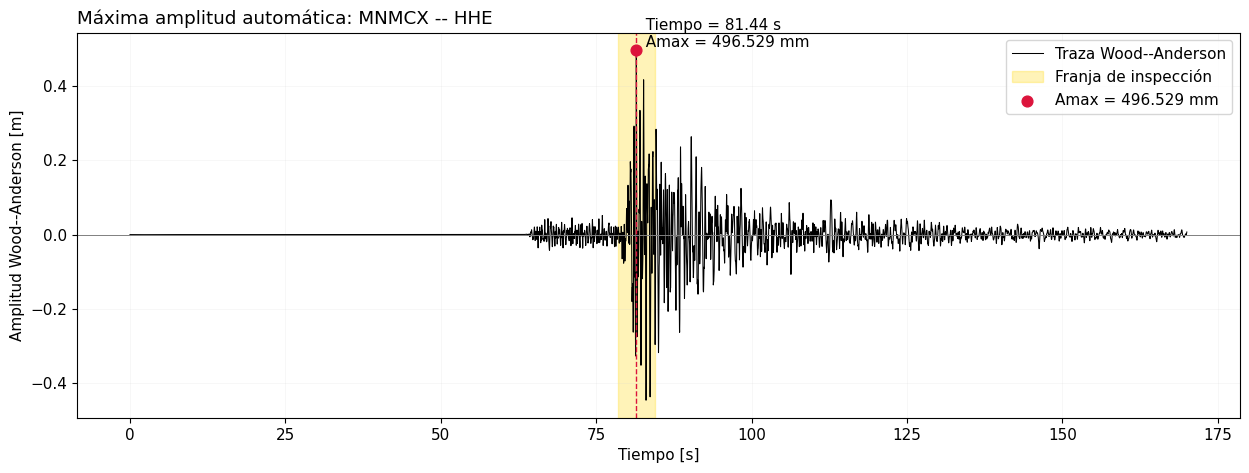

Máximo absoluto para MNMCX -- HHE:
Amax = 4.965290e-01 m
Amax = 496.529000 mm
Tiempo de Amax = 81.44 s


In [4]:
ESTACION_EJEMPLO = "MNMCX"
COMPONENTE_EJEMPLO = "HHE"

# Semiancho de la franja visual alrededor de la amplitud máxima.
VENTANA_SEMIALTURA_S = 3.0

clave_ejemplo = (ESTACION_EJEMPLO, COMPONENTE_EJEMPLO)

if clave_ejemplo not in trazas_wa:
    raise KeyError(
        f"No existe la traza {clave_ejemplo}.\n"
        f"Claves disponibles:\n{list(trazas_wa.keys())}"
    )

datos = trazas_wa[clave_ejemplo]["datos"]

t = datos["t_s"].to_numpy()
u_m = datos["amplitud_m"].to_numpy()

indice_max = np.argmax(np.abs(u_m))

t_max = t[indice_max]
u_max_firmada_m = u_m[indice_max]
A_max_m = abs(u_max_firmada_m)
A_max_mm = A_max_m * 1000.0

t_ini = max(t.min(), t_max - VENTANA_SEMIALTURA_S)
t_fin = min(t.max(), t_max + VENTANA_SEMIALTURA_S)

plt.figure(figsize=(15, 5))

plt.plot(
    t,
    u_m,
    color="black",
    lw=0.75,
    label="Traza Wood--Anderson"
)

plt.axvspan(
    t_ini,
    t_fin,
    color="gold",
    alpha=0.28,
    label="Franja de inspección"
)

plt.scatter(
    t_max,
    u_max_firmada_m,
    color="crimson",
    s=60,
    zorder=3,
    label=f"Amax = {A_max_mm:.3f} mm"
)

plt.axhline(0, color="gray", lw=0.7)
plt.axvline(t_max, color="crimson", ls="--", lw=1)

texto_y = (
    u_max_firmada_m
    if u_max_firmada_m >= 0
    else u_max_firmada_m
)

alineacion_vertical = "bottom" if u_max_firmada_m >= 0 else "top"

plt.text(
    t_max,
    texto_y,
    (
        f"  Tiempo = {t_max:.2f} s\n"
        f"  Amax = {A_max_mm:.3f} mm"
    ),
    va=alineacion_vertical
)

plt.title(
    f"Máxima amplitud automática: "
    f"{ESTACION_EJEMPLO} -- {COMPONENTE_EJEMPLO}",
    loc='left'
)

plt.xlabel("Tiempo [s]")
plt.ylabel("Amplitud Wood--Anderson [m]")
plt.legend()
plt.savefig("/home/keneth/Documents/Academic_Projects/AGCID2026_DIS_UChile/Week3/Figures/amplitud_maxima_automatica.png", dpi=300, bbox_inches="tight")
plt.show()

print(
    f"Máximo absoluto para {ESTACION_EJEMPLO} -- "
    f"{COMPONENTE_EJEMPLO}:"
)

print(f"Amax = {A_max_m:.6e} m")
print(f"Amax = {A_max_mm:.6f} mm")
print(f"Tiempo de Amax = {t_max:.2f} s")

## 4. Cálculo de amplitudes máximas para todas las estaciones

La función siguiente calcula la amplitud máxima absoluta de cada traza horizontal:

$$
A_{\max} = \max |u(t)|.
$$

Se muestran dos tablas:

1. **Resultados por componente:** contiene el tiempo del máximo, la amplitud firmada, la amplitud máxima en metros y la amplitud máxima en milímetros.
2. **Resumen por estación:** compara las amplitudes máximas de las componentes E y N.

La amplitud media por estación se presenta sólo como referencia. Para calcular $M_L$, se calcula la magnitud individual de cada componente y después se promedian ambas magnitudes.

In [5]:
def calcular_amplitudes_maximas(trazas):
    """
    Calcula Amax = max(abs(amplitud)) para cada traza horizontal.
    """
    filas = []

    for (estacion, componente), info in sorted(trazas.items()):
        datos = info["datos"]

        t = datos["t_s"].to_numpy()
        u_m = datos["amplitud_m"].to_numpy()

        indice = np.argmax(np.abs(u_m))

        amplitud_firmada_m = u_m[indice]
        amplitud_maxima_m = abs(amplitud_firmada_m)

        filas.append({
            "Estación": estacion,
            "Componente": componente,
            "Red": info["red"],
            "Archivo": info["archivo"],
            "Tiempo de Amax [s]": t[indice],
            "Amplitud firmada [m]": amplitud_firmada_m,
            "Amax [m]": amplitud_maxima_m,
            "Amax [mm]": amplitud_maxima_m * 1000.0
        })

    return pd.DataFrame(filas).sort_values(
        ["Estación", "Componente"]
    ).reset_index(drop=True)


tabla_amplitudes_componentes = calcular_amplitudes_maximas(
    trazas_wa
)

tabla_amplitudes_estaciones = (
    tabla_amplitudes_componentes
    .pivot(
        index="Estación",
        columns="Componente",
        values="Amax [mm]"
    )
    .rename(
        columns={
            "HHE": "Amax E [mm]",
            "HHN": "Amax N [mm]"
        }
    )
    .reset_index()
)

columnas_amplitud = [
    columna
    for columna in tabla_amplitudes_estaciones.columns
    if columna.startswith("Amax ")
    and "media" not in columna.lower()
]

tabla_amplitudes_estaciones["Amax media [mm]"] = (
    tabla_amplitudes_estaciones[columnas_amplitud].mean(axis=1)
)

print("Resultados de amplitud máxima por componente:")
tabla_amplitudes_componentes

Resultados de amplitud máxima por componente:


,Estación,Componente,Red,Archivo,Tiempo de Amax [s],Amplitud firmada [m],Amax [m],Amax [mm]
0,MNMCX,HHE,CX,CX.MNMCX..HHE.dat,81.44,0.496529,0.496529,496.529
1,MNMCX,HHN,CX,CX.MNMCX..HHN.dat,81.18,-0.405633,0.405633,405.633
2,PATA,HHE,IQ,IQ.PATA..HHE.dat,79.67,0.622355,0.622355,622.355
3,PATA,HHN,IQ,IQ.PATA..HHN.dat,80.00,-0.540335,0.540335,540.335
4,PB07,HHE,CX,CX.PB07..HHE.dat,92.64,-0.156229,0.156229,156.229
5,PB07,HHN,CX,CX.PB07..HHN.dat,92.71,-0.143698,0.143698,143.698
6,PSGCX,HHE,CX,CX.PSGCX..HHE.dat,79.33,-0.140031,0.140031,140.031
7,PSGCX,HHN,CX,CX.PSGCX..HHN.dat,78.80,-0.144421,0.144421,144.421
8,UNAP,HHE,IQ,IQ.UNAP..HHE.dat,75.24,0.288775,0.288775,288.775
9,UNAP,HHN,IQ,IQ.UNAP..HHN.dat,75.59,0.287222,0.287222,287.222


In [6]:
print("\nResumen de amplitudes por estación:")
tabla_amplitudes_estaciones


Resumen de amplitudes por estación:


Componente,Estación,Amax E [mm],Amax N [mm],Amax media [mm]
0,MNMCX,496.529,405.633,451.0810
1,PATA,622.355,540.335,581.3450
2,PB07,156.229,143.698,149.9635
3,PSGCX,140.031,144.421,142.2260
4,UNAP,288.775,287.222,287.9985


## 5. Cálculo de $M_L$ por componente y por estación

Para cada componente horizontal se calcula:

$$
-\log_{10}(A_0)
=
\log_{10}\left(\frac{\Delta}{100}\right)
+
3,
$$

y posteriormente:

$$
M_L
=
\log_{10}(A_{\mathrm{mm}})
+
\log_{10}\left(\frac{\Delta}{100}\right)
+
3.
$$

La tabla de resultados incluye:

- Nombre de la estación.
- Distancia epicentral $\Delta$.
- Componente horizontal.
- Amplitud máxima en milímetros.
- Corrección de distancia.
- Magnitud local por componente.

Luego se genera una segunda tabla con las magnitudes de las componentes E y N, junto con el promedio de la estación.

In [7]:
def calcular_ml(A_mm, delta_km):
    """
    Calcula Ml usando amplitud máxima en mm y distancia epicentral en km.

    Ml = log10(A_mm) + log10(delta_km / 100) + 3
    """
    if A_mm <= 0:
        return np.nan

    return (
        np.log10(A_mm)
        + np.log10(delta_km / 100.0)
        + 3.0
    )


def calcular_tabla_ml(tabla_amplitudes, distancias_km):
    """
    Calcula Ml por componente y el promedio de Ml por estación.
    """
    tabla = tabla_amplitudes.copy()

    tabla["Distancia epicentral Δ [km]"] = (
        tabla["Estación"].map(distancias_km)
    )

    tabla["Corrección -log10(A0)"] = (
        np.log10(
            tabla["Distancia epicentral Δ [km]"] / 100.0
        )
        + 3.0
    )

    tabla["Ml por componente"] = [
        calcular_ml(A_mm, delta_km)
        for A_mm, delta_km in zip(
            tabla["Amax [mm]"],
            tabla["Distancia epicentral Δ [km]"]
        )
    ]

    resumen = (
        tabla
        .pivot(
            index="Estación",
            columns="Componente",
            values="Ml por componente"
        )
        .rename(
            columns={
                "HHE": "Ml E",
                "HHN": "Ml N"
            }
        )
        .reset_index()
    )

    resumen["Distancia epicentral Δ [km]"] = (
        resumen["Estación"].map(distancias_km)
    )

    columnas_ml = [
        columna
        for columna in resumen.columns
        if columna.startswith("Ml ")
    ]

    resumen["Ml estación (promedio E-N)"] = (
        resumen[columnas_ml].mean(axis=1)
    )

    columnas_finales = [
        "Estación",
        "Distancia epicentral Δ [km]",
        "Ml E",
        "Ml N",
        "Ml estación (promedio E-N)"
    ]

    resumen = (
        resumen[columnas_finales]
        .sort_values("Estación")
        .reset_index(drop=True)
    )

    return tabla, resumen


tabla_ml_componentes, tabla_ml_estaciones = calcular_tabla_ml(
    tabla_amplitudes=tabla_amplitudes_componentes,
    distancias_km=DISTANCIAS_EPICENTRALES_KM
)

print("Magnitud local por componente:")
tabla_ml_componentes

Magnitud local por componente:


,Estación,Componente,Red,Archivo,Tiempo de Amax [s],Amplitud firmada [m],Amax [m],Amax [mm],Distancia epicentral Δ [km],Corrección -log10(A0),Ml por componente
0,MNMCX,HHE,CX,CX.MNMCX..HHE.dat,81.44,0.496529,0.496529,496.529,113.7,3.055760,5.751705
1,MNMCX,HHN,CX,CX.MNMCX..HHN.dat,81.18,-0.405633,0.405633,405.633,113.7,3.055760,5.663894
2,PATA,HHE,IQ,IQ.PATA..HHE.dat,79.67,0.622355,0.622355,622.355,93.0,2.968483,5.762521
3,PATA,HHN,IQ,IQ.PATA..HHN.dat,80.00,-0.540335,0.540335,540.335,93.0,2.968483,5.701146
4,PB07,HHE,CX,CX.PB07..HHE.dat,92.64,-0.156229,0.156229,156.229,185.9,3.269279,5.463041
5,PB07,HHN,CX,CX.PB07..HHN.dat,92.71,-0.143698,0.143698,143.698,185.9,3.269279,5.426730
6,PSGCX,HHE,CX,CX.PSGCX..HHE.dat,79.33,-0.140031,0.140031,140.031,100.7,3.003029,5.149254
7,PSGCX,HHN,CX,CX.PSGCX..HHN.dat,78.80,-0.144421,0.144421,144.421,100.7,3.003029,5.162660
8,UNAP,HHE,IQ,IQ.UNAP..HHE.dat,75.24,0.288775,0.288775,288.775,84.8,2.928396,5.388955
9,UNAP,HHN,IQ,IQ.UNAP..HHN.dat,75.59,0.287222,0.287222,287.222,84.8,2.928396,5.386614


In [8]:
print("\nMagnitud local promedio por estación:")
tabla_ml_estaciones


Magnitud local promedio por estación:


Componente,Estación,Distancia epicentral Δ [km],Ml E,Ml N,Ml estación (promedio E-N)
0,MNMCX,113.7,5.751705,5.663894,5.707799
1,PATA,93.0,5.762521,5.701146,5.731834
2,PB07,185.9,5.463041,5.426730,5.444886
3,PSGCX,100.7,5.149254,5.162660,5.155957
4,UNAP,84.8,5.388955,5.386614,5.387784


## 6. Magnitud local final y error estadístico

La magnitud local final se calcula como el promedio de las magnitudes obtenidas para las estaciones:

$$
\overline{M_L}
=
\frac{1}{N}
\sum_{i=1}^{N}
M_{L,i}.
$$

Además, se calculan dos medidas de variabilidad:

- **Desviación estándar muestral:** mide la dispersión de las magnitudes estimadas entre estaciones.
- **Error estándar de la media:**

$$
\mathrm{SEM}
=
\frac{s}{\sqrt{N}},
$$

donde $s$ es la desviación estándar muestral y $N$ es el número de estaciones utilizadas.

El resultado final puede reportarse como:

$$
M_L = \overline{M_L} \pm \mathrm{SEM}.
$$

El error estándar representa la incertidumbre estadística asociada a la media entre estaciones; no incluye todas las posibles incertidumbres de modelo, instrumentación o selección de señal.

In [9]:
ml_por_estacion = (
    tabla_ml_estaciones["Ml estación (promedio E-N)"]
    .dropna()
    .to_numpy()
)

n_estaciones = len(ml_por_estacion)

Ml_final = np.mean(ml_por_estacion)

desviacion_estandar = (
    np.std(ml_por_estacion, ddof=1)
    if n_estaciones > 1
    else np.nan
)

error_estandar = (
    desviacion_estandar / np.sqrt(n_estaciones)
    if n_estaciones > 1
    else np.nan
)

mediana_ml = np.median(ml_por_estacion)

resumen_final = pd.DataFrame([
    {
        "Número de estaciones": n_estaciones,
        "Ml promedio final": Ml_final,
        "Mediana de Ml": mediana_ml,
        "Desviación estándar entre estaciones": desviacion_estandar,
        "Error estándar de la media": error_estandar
    }
])

print(
    f"Resultado obtenido:\n"
    f"Ml = {Ml_final:.2f} ± {error_estandar:.2f} "
    f"(error estándar; N = {n_estaciones})"
)

print(
    f"Desviación estándar entre estaciones: "
    f"σ = {desviacion_estandar:.2f}"
)
resumen_final

Resultado obtenido:
Ml = 5.49 ± 0.11 (error estándar; N = 5)
Desviación estándar entre estaciones: σ = 0.24


,Número de estaciones,Ml promedio final,Mediana de Ml,Desviación estándar entre estaciones,Error estándar de la media
0,5,5.485652,5.444886,0.239736,0.107213


In [10]:
from pathlib import Path
import subprocess
import sys

NOTEBOOK = Path("Calculo_ML.ipynb")

if not NOTEBOOK.exists():
    raise FileNotFoundError(
        f"No se encontró el notebook:\n{NOTEBOOK.resolve()}\n\n"
        "Guarda primero el notebook y actualiza la variable NOTEBOOK "
        "con su nombre o ruta correcta."
    )

comando = [
    sys.executable,
    "-m",
    "jupyter",
    "nbconvert",
    "--to",
    "pdf",
    "--PDFExporter.exclude_input=False",
    str(NOTEBOOK)
]

try:
    resultado = subprocess.run(
        comando,
        check=True,
        text=True,
        capture_output=True
    )

    pdf = NOTEBOOK.with_suffix(".pdf")

    print(resultado.stdout)

    if pdf.exists():
        print(f"PDF creado correctamente:\n{pdf.resolve()}")
    else:
        print(
            "El comando terminó sin error, pero no se encontró el PDF "
            "en la ubicación esperada."
        )

except subprocess.CalledProcessError as error:
    print("No fue posible exportar el notebook a PDF.\n")
    print("Salida estándar:")
    print(error.stdout)
    print("\nMensajes de error:")
    print(error.stderr)


PDF creado correctamente:
/home/keneth/Documents/Academic_Projects/AGCID2026_DIS_UChile/Week3/Task_Files/Calculo_ML.pdf
